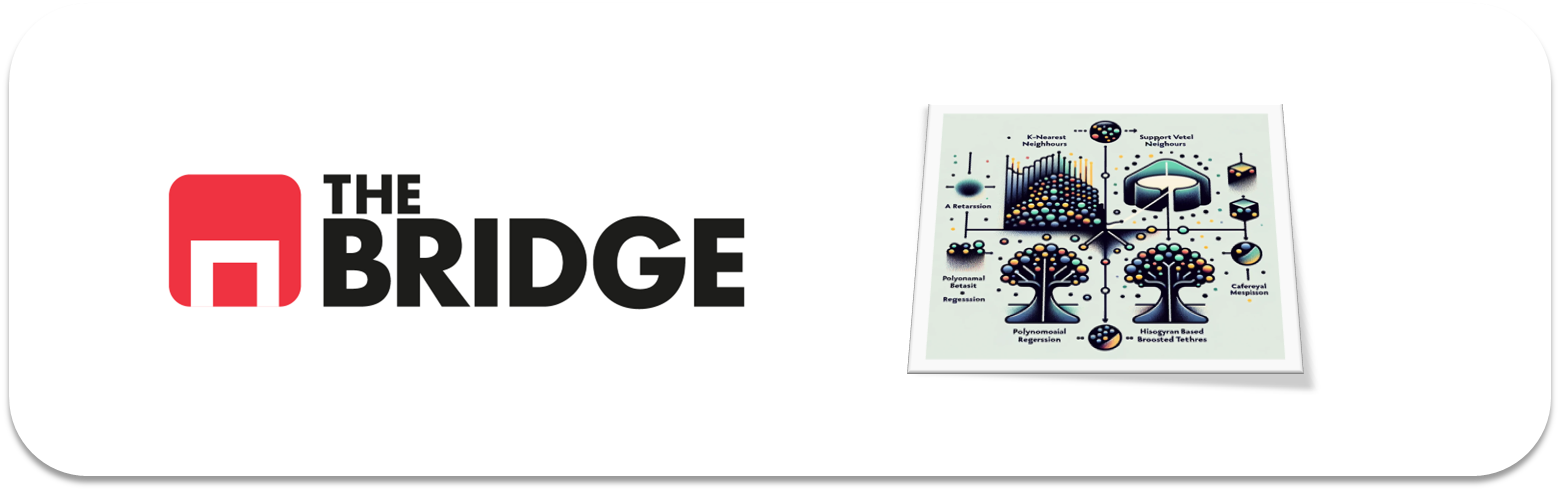

# Otros Modelos: Support Vector Machine

### Concepto y modelado lineal para clasificación


En esta primera parte te explico muy por encima el concepto que hay detrás del modelo, pero no es fundamental que lo memorices.

Partimos de este conjunto de datos y queremos hacer un modelo de clasificación

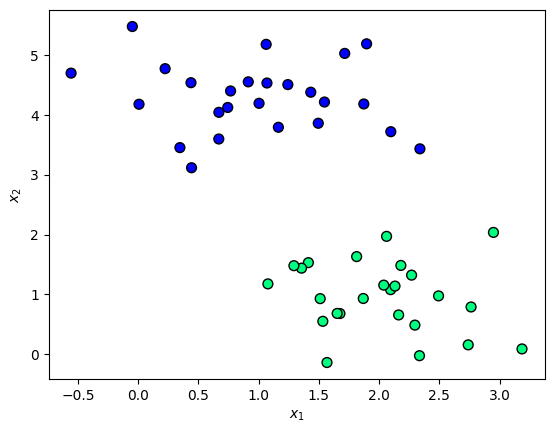

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter',edgecolors='k');
plt.xlabel('$x_1$')
plt.ylabel('$x_2$');

Existen infinitos separadores (modelos) que separan perfectamente ambas clases

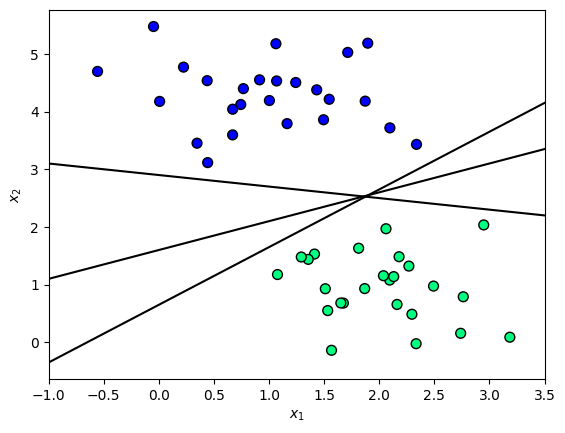

In [2]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter',edgecolors='k')


for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    plt.plot(xfit, m * xfit + b, '-k')

plt.xlim(-1, 3.5);
plt.xlabel('$x_1$')
plt.ylabel('$x_2$');

¿Cuál es el mejor separador? 

Empecemos analizando cuál es el separador de la regresión logística

In [3]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)
lr.fit(X,y)
lr.intercept_, lr.coef_

(array([4.81433718]), array([[ 0.57337249, -2.18045686]]))

$\Large y = \theta(4.81 + 0.573x_1 - 2.18x_2)$, donde $\Large \theta$ es la función sigmoide:

<>:9: SyntaxWarning: invalid escape sequence '\T'
<>:9: SyntaxWarning: invalid escape sequence '\T'
C:\Users\rebec\AppData\Local\Temp\ipykernel_10804\3989652742.py:9: SyntaxWarning: invalid escape sequence '\T'
  plt.ylabel('$\Theta(s)$')


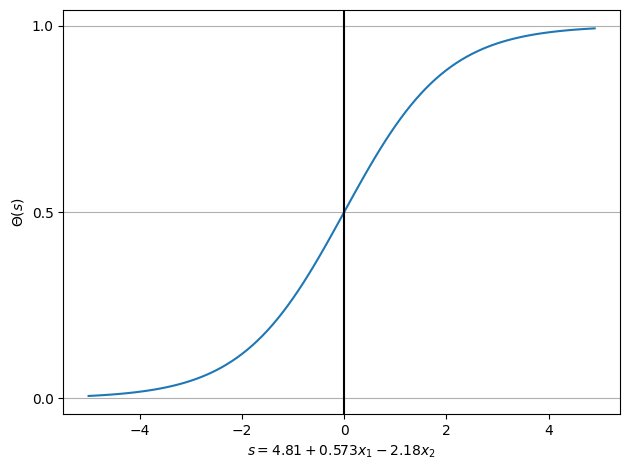

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
z = np.arange(-5, 5, 0.1)
phi_z = sigmoid(z)
 
plt.plot(z, phi_z)
plt.axvline(0.0, color='k')
plt.xlabel('$s=4.81 + 0.573x_1 - 2.18x_2$')
plt.ylabel('$\Theta(s)$')
plt.yticks([0.0, 0.5, 1.0])
ax = plt.gca()
ax.yaxis.grid(True)
plt.tight_layout()
plt.show()

En regresión logística, la predicción queda determinada por la ecuación $\theta(s)=\theta(w_0+w_1x_1+w_2x_2+...+w_Nx_N)$. Cuando $s=0$,  $\theta(s)=0.5$, que suele ser el umbral para clasificar una categoría u otra. 

En este ejemplo $s=4.81 + 0.573x_1 - 2.18x_2$. Si igualamos a cero, obtenemos la ecuación de la recta separadora:

$4.81 + 0.573x_1 - 2.18x_2=0$  
  
$2.18x_2 = 0.573x_1 + 4.81$   
  
$x_2=\frac{0.573}{2.18}x_1 + \frac{4.81}{2.18}$
  
$x_2 = 0.263x_1 + 2.206 $

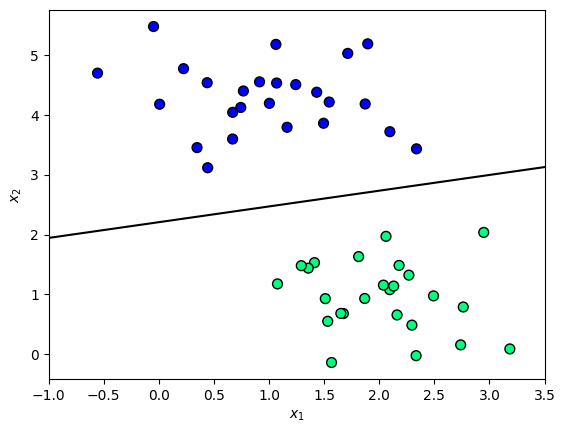

In [5]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter',edgecolors='k')
m=0.263
b=2.206
plt.plot(xfit, m * xfit + b, '-k')
plt.xlim(-1, 3.5);
plt.xlabel('$x_1$')
plt.ylabel('$x_2$');

**Support vector machines** busca establecer un separador con el mayor margen posible a las muestras más cercanas

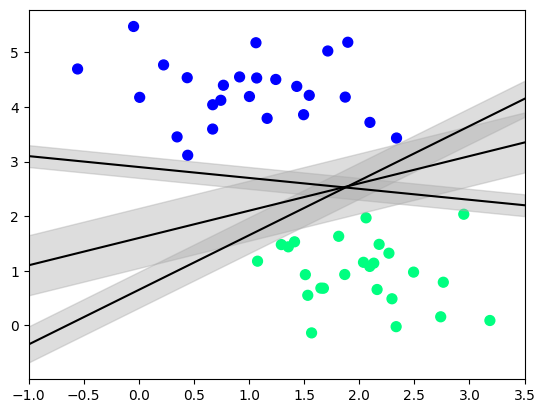

In [6]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')

for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='#AAAAAA', alpha=0.4)

plt.xlim(-1, 3.5);

La recta separadora que maximice este margen será escogida como el mejor modelo.

In [7]:
from sklearn.svm import SVC # "support vector classifier"

model = SVC(kernel='linear', C=1e10)
model.fit(X,y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10000000000.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Fíjate por un segundo antes de seguir que existe ese argumento kernel (luego volveremos a él)

In [9]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1,facecolors='none', edgecolors='r');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

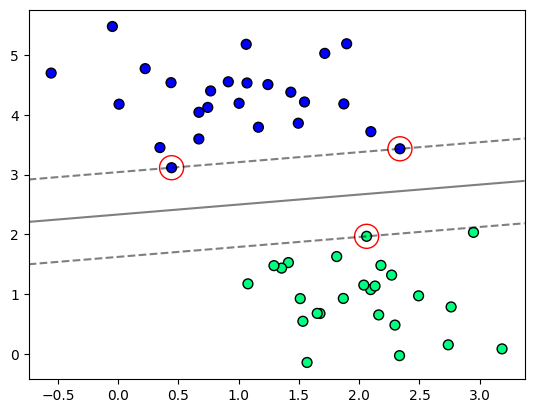

In [10]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter',edgecolors='k');
plot_svc_decision_function(model);


Esta recta separadora maximiza el margen entre los dos conjuntos de puntos. Fíjate que alguno de los puntos están justo en el margen, indicados con círculos rojos. Estos puntos son los vectores de soporte, que dan nombre al algoritmo.

In [11]:
model.support_vectors_

array([[0.44359863, 3.11530945],
       [2.33812285, 3.43116792],
       [2.06156753, 1.96918596]])

Si pintamos la recta de la regresión logística que calculamos anteriormente, vemos que no es exactamente la misma

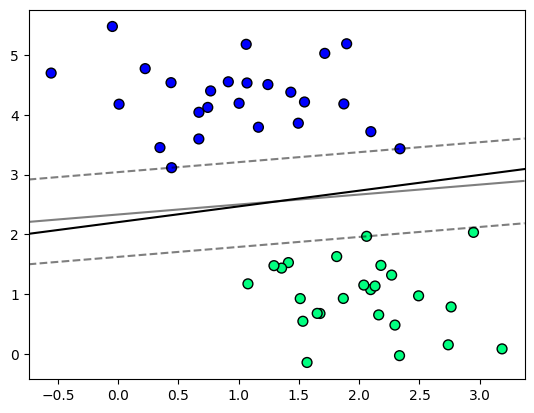

In [12]:
# Datos
plt.scatter(X[:,0], X[:,1], c=y, s=50, cmap='winter', edgecolors='k')

# SVM
plot_svc_decision_function(model, plot_support=False)

# Regresión Logística
xfit = np.linspace(-1, 3.5)
m=0.263
b=2.206
plt.plot(xfit, m * xfit + b, '-k')

**

### Matizaciones

* Este algoritmo es sensible al escalado de las variables

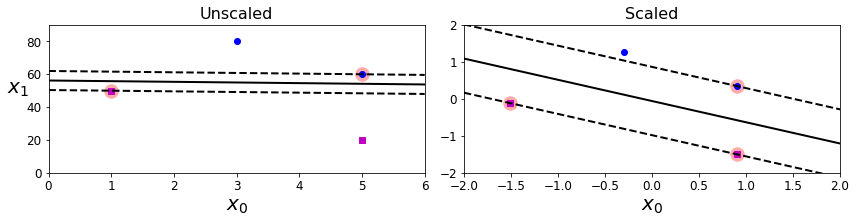

* Este algoritmo es muy sensible a outliers, hay que tratarlos (quitarlos y luego considerar esos puntos con otro modelo por ejemplo)

* Es muy sensible a la existencia de una zona de soporte (de margen entre las clases). Por eso tiene un hiperparámetros C que permite que algunos puntos caigan en la zona de soporte o seguridad. A C más alto más estricto.

En general no es un modelo que nosotros vayamos a utilizar, pero puede que tú si quieras probarlo y alguna vez lo necesites. [Aquí](https://scikit-learn.org/stable/modules/svm.html) tienes una referencia para profundizar más. Nosotros vamos a limitarnos a presentar otros "kernels" y su concepto y ahí lo dejamos.

### Kernels: SVM como clasificadores no lineales

Una forma un poco "grosera" de ver la generalización de este tipo de modelos es considerar los conceptos del apartado anterior pero en que antes de aplicarlos a los datos se les transforma (como hacíamos con la transformación a polinomio de las regresiones lineales en la sesión anterior). A esa transformación previa se le denomina "kernelización" o sea aplicación de un kernel o transformación. De hecho SVM tiene un "kernel" ("poly") con el que se imita prácticamente una regresión polinómica.

Vamos a ver dos kernel (no hace falta que te aprendas la fórmula matemática que sigue es por pura completitud teórica)[NOTA: ya hemos visto una más el "linear" que es el que hemos aplicado antes]

**Kernel polinómico**: Transformamos la dimensión de entrada a través de un polinomio de grado *d*. Por ejemplo, para $d=2$: 
$(x_1, x_2) \rightarrow (x_1, x_2, x_1x_2, x_1^2, x_2^2)$  

**Kernel RBF (Radial Basis Function)**: traslada los datos a una dimensión infinita  
$(x_1, x_2) \rightarrow \exp(-\gamma||x_1 - x_2||^2)$

Veamos algún ejemplo con datos no linealmente separables

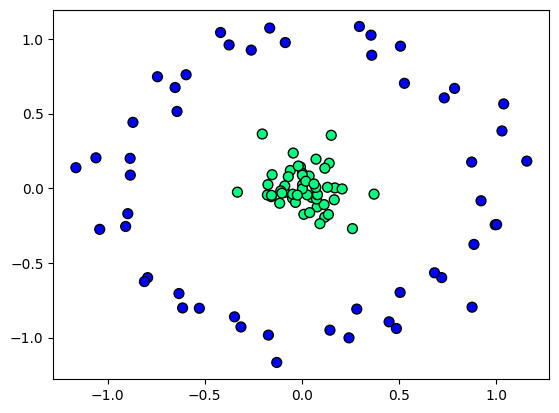

In [13]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter',edgecolors='k');

**Kernel lineal**

In [14]:
from sklearn.svm import SVC 
clf = SVC(kernel='linear').fit(X,y) # Se instancia igual, solo hay que cambiar el argumenot 'kernel'

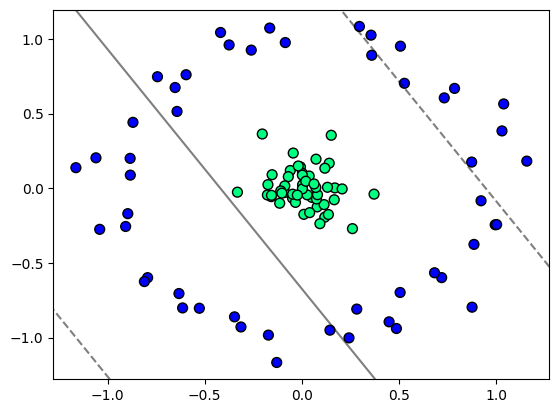

In [15]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter',edgecolors='k')
plot_svc_decision_function(clf, plot_support=False);

**Kernel polinómico de grado 2**

In [16]:
clf = SVC(kernel='poly', degree=2,C=1e6)
clf.fit(X,y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1000000.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",2
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


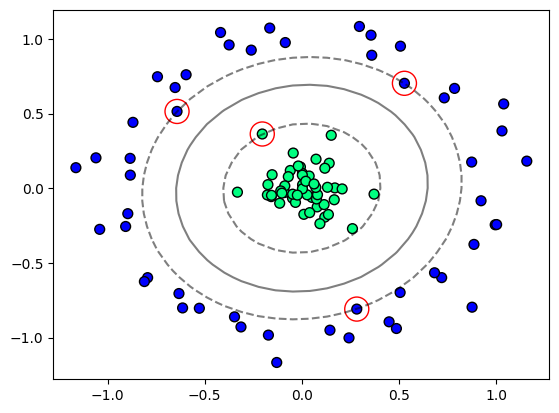

In [17]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter',edgecolors='k')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none');

**Kernel RBF**

In [18]:
clf = SVC(kernel='rbf', C=1e6)
clf.fit(X,y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1000000.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


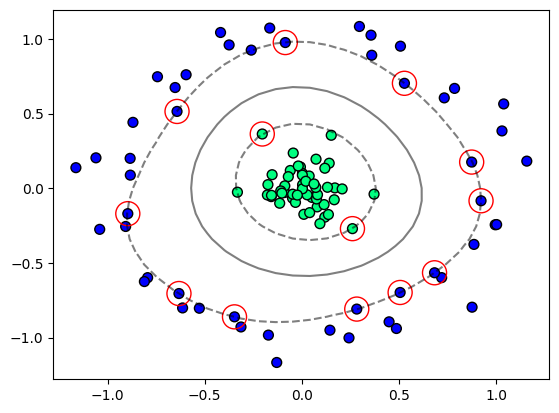

In [19]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter',edgecolors='k')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none');

### SVM en regresión

Aunque SVM es conocido por ser un modelo de clasificación, también puede utilizarse en regresiones, siendo su planteamiento muy similar, aunque no vamos a profundizar en ello, solo vamos a ver cómo se aplica:


In [20]:
import numpy as np
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

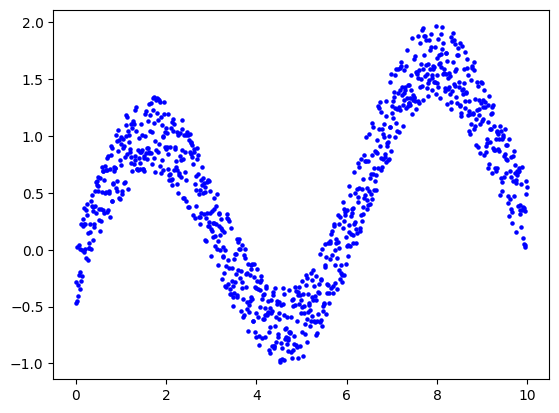

In [21]:
np.random.seed(21)

N =1000

def makeData(x):
    r = [a/10 for a in x]
    y = np.sin(x)+np.random.uniform(-0.5, 0.2, len(x))
    return np.array(y+r)

x = [i/100 for i in range(N)]
y = makeData(x)
x = np.array(x).reshape(-1,1)

plt.scatter(x,y,s=5,color="blue");

In [22]:
svr = SVR() # Por defecto el kernel es el RBF
svr.fit(x,y)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [23]:
yfit = svr.predict(x)

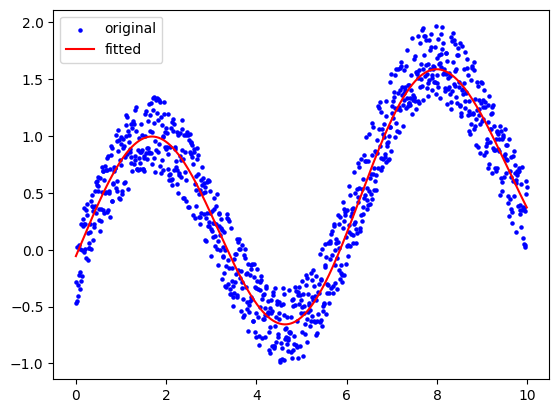

In [24]:
plt.scatter(x, y, s=5, color="blue", label='original')
plt.plot(x, yfit, color="red", label='fitted')
plt.legend()
plt.show()

In [25]:
score = svr.score(x, y)
print('R-squared:', score)
print('MSE:', mean_squared_error(y,yfit))

R-squared: 0.9201610722643554
MSE: 0.041676600207571246
